In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re

matrix_path = "/home/mengelsl/MA-bench-framework/matrices/spmv"

def get_mb(n, randomness):
    r_str = str(randomness).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(n)}.bin")
    try:
        return round(os.path.getsize(f_path) / (1024**2))
    except: return None

main_folder = {
    "Native": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/native/",
    "SME": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme/",
    "SME+SEV": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev/",
    "Native_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/native_interleave/",
    "SME_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme_interleave/",
    "SME+SEV_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev_interleave/",
}

config_cols = ["Mode", "Matrix", "Cores", "Process_NUMA", "VM_NUMA", "Iterations"]

metrics = [
    "IO_Time", "SpMV_Time", "SpMV_GFLOPS", "Perf_Cycles",
    "Perf_Instructions", "Perf_CacheMisses", "Perf_dTLBMisses",
    "Voluntary_CtxSwitches", "Involuntary_CtxSwitches",
    "Minor_Faults", "Major_Faults", "Peak_RSS"
]

Loaded 7200 raw rows.


# Data Validity per Iter

In [56]:
iter_list = []

for label, base_path in main_folder.items():
    extra_path = os.path.join(base_path, "extra")
    
    for folder in os.listdir(extra_path):
        csv_p = os.path.join(extra_path, folder, "iter.csv")
        match = re.search(r'(\d-\d)_N(\d+)_c(\d+)_(\w+)', folder)
        
        if os.path.exists(csv_p) and match:
            it_df = pd.read_csv(csv_p)
            it_df['Mode'] = label.replace("_interleave", "")
            it_df['Randomness'] = float(match.group(1).replace('-', '.'))
            it_df['N'] = int(match.group(2))
            it_df['Cores'] = int(match.group(3))
            it_df['Process_NUMA'] = match.group(4)
            it_df['VM_NUMA'] = "interleave" if "interleave" in label else "strict"
            it_df['MB'] = get_mb(it_df['N'].iloc[0], it_df['Randomness'].iloc[0])
            iter_list.append(it_df)

# This takes ~1-2 minutes
df_iters = pd.concat(iter_list, ignore_index=True) 
print(f"Loaded {len(df_iters)} individual iterations.")

Loaded 408661650 individual iterations.


In [61]:
def downsample_with_run_medians(df, group_cols, n_points=200):
    def process_config(config_group):
        unique_iters = np.sort(config_group['Iter'].unique())
        
        if len(unique_iters) <= n_points:
            target_iters = unique_iters
        else:
            idx = np.linspace(0, len(unique_iters) - 1, n_points).astype(int)
            target_iters = unique_iters[idx]
        
        sampled_all_runs = config_group[config_group['Iter'].isin(target_iters)]
        final_points = (
            sampled_all_runs.groupby('Iter')['Time']
            .median()
            .reset_index()
        )
        
        # Get group values from the original groupby keys
        group_values = {col: config_group[col].iloc[0] for col in group_cols}
        for col, val in group_values.items():
            final_points[col] = val
            
        final_points["IterNorm"] = np.linspace(0, 1, len(final_points))
        return final_points

    return (
        df.groupby(group_cols, group_keys=False)
          .apply(process_config, include_groups=False)
          .reset_index(drop=True)
    )

group_cols = ['Mode', 'MB', 'Cores', 'VM_NUMA', 'Process_NUMA', 'Randomness']
df_iters_small = downsample_with_run_medians(df_iters, group_cols, n_points=200)

/tmp/ipykernel_2723822/2137798145.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(group_cols, group_keys=False)


In [126]:
def get_config_stability(group, window_size=10, threshold_pct=5.0):
    # skip first (warmup)
    times = group['Time'].values[1:]

    #see if there are individual groups with too few iterations to analyze
    if len(times) < window_size:
        return pd.Series({"P2P_Shift_Pct": np.nan, "Is_Straight": False, "Too_Small": True})

    rolling_filtered = pd.Series(times).rolling( window=window_size, center=True, ).mean()

    # .dropna() removes the edge NaNs 
    valid_rolling = rolling_filtered.dropna()

    global_med = np.median(times)
    p2p_shift = (valid_rolling.max() - valid_rolling.min()) / global_med * 100
    
    return pd.Series({
        "P2P_Shift_Pct": p2p_shift,
        "Is_Straight": p2p_shift < threshold_pct,
        "Too_Small": False,
    })

stability_report = df_iters_small.groupby(group_cols).apply(
    get_config_stability, 
    include_groups=False
).reset_index()

stability_report_relevant = stability_report[~stability_report["Too_Small"]]
passed = stability_report_relevant["Is_Straight"].sum()
total = len(stability_report_relevant)

print(f"Configurations analyzed (with a large enough sample size): {total} of {len(stability_report)}")
print(f"Configs with NO plateau shifts: {passed} of {total} ({passed/total:.1%})")

Configurations analyzed (with a large enough sample size): 468 of 480
Configs with NO plateau shifts: 458 of 468 (97.9%)


In [127]:
#lets look at those with too few iterations and then those with shifts
few_iter = df_iters_small.merge(
    stability_report[stability_report["Too_Small"]],
    on=group_cols, 
    how='inner'
)

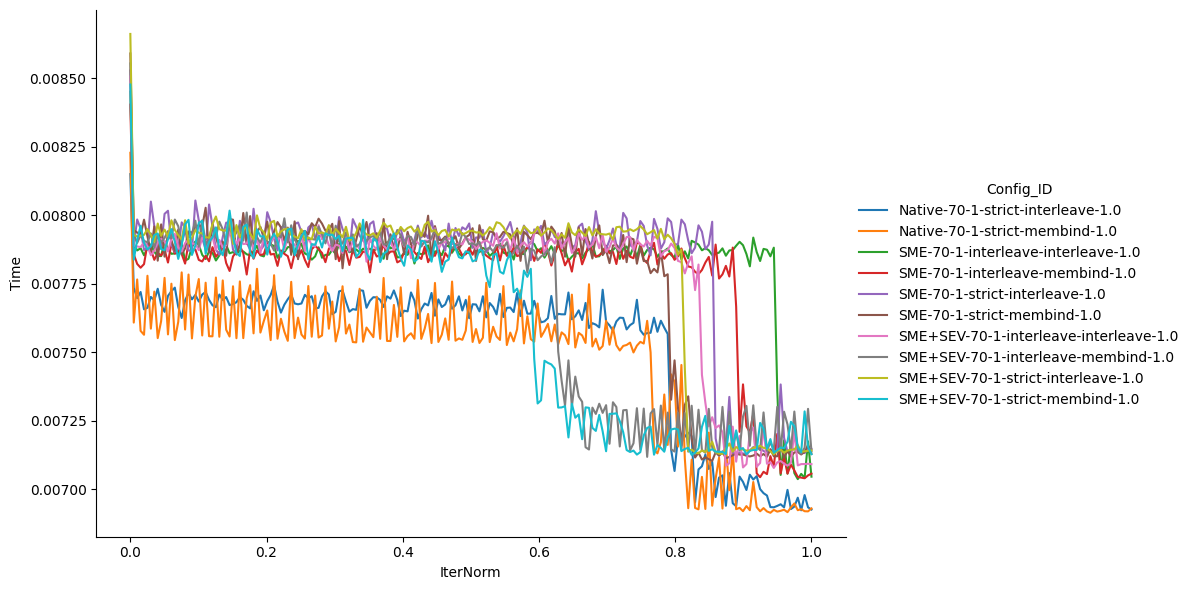

In [ ]:
platue_shifted = df_iters_small.merge(
    stability_report[~stability_report["Is_Straight"] & ~stability_report["Too_Small"]],
    on=group_cols,
    how='inner'
)
platue_shifted['Config_ID'] = platue_shifted[group_cols].astype(str).agg('-'.join, axis=1)

sns.relplot(
    data=platue_shifted, 
    x="IterNorm", 
    y="Time", 
    hue="Config_ID", 
    kind="line", 
    estimator=None,
    height=6, 
    aspect=1.5
)
 
#Lets still keep those as deleting them would skew the overall data, but keep in mind they are not stable and the 70MB Random Matrix might differ in some regard

# Also look at the 2 other native ones and figure out how much the differnce between plateus is to justify keeping them in the overall analysis

In [ ]:
# See visually that most configs are stable

for rnd in sorted(df_iters_small["Randomness"].dropna().unique()):
    for vm in sorted(df_iters_small["VM_NUMA"].dropna().unique()):
        for proc in sorted(df_iters_small["Process_NUMA"].dropna().unique()):
            sub = df_iters_small[
                (df_iters_small["Randomness"] == rnd) &
                (df_iters_small["VM_NUMA"] == vm) &
                (df_iters_small["Process_NUMA"] == proc)
            ].copy()

            if sub.empty:
                continue

            sub = sub.sort_values("IterNorm")

            g = sns.relplot(
                data=sub,
                kind="line",
                x="IterNorm",
                y="Time",
                hue="Mode",
                row="MB",
                col="Cores",
                errorbar=None,
                sort=False,
                palette="viridis",
                facet_kws={"sharey": False, "sharex": True},
                alpha=0.7,
                height=2.3,
                aspect=1.1
            )

            g.set_axis_labels("Normalized iteration progress", "Time (ms)")
            g.set_titles("MB: {row_name} | Cores: {col_name}")
            g.set(xlim=(0, 1), xticks=np.linspace(0, 1, 5))
            g.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
            g.fig.suptitle(
                f"Time over Iter | Randomness={rnd} | VM_NUMA={vm} | Process_NUMA={proc}",
                y=1.02
            )
            g.tight_layout()
            plt.show()

# Full results

In [ ]:
results_list = []

for label, path in main_folder.items():
    f_path = os.path.join(path, "results.csv")
    if os.path.exists(f_path):
        df = pd.read_csv(f_path)
        df["Mode"] = label.replace("_interleave", "")
        df["VM_NUMA"] = "interleave" if "interleave" in label else "strict"
        results_list.append(df)

df_raw = pd.concat(results_list, ignore_index=True)
df_raw.rename(columns={"NUMA_Policy": "Process_NUMA"}, inplace=True)

print(f"Loaded {len(df_raw)} raw rows.")

In [2]:
config_drop_counts = []

def iqr_mark_outliers(group):
    group = group.copy()
    group_drops = 0

    for col in metrics:
        if col not in group.columns:
            continue
        
        data = pd.to_numeric(group[col], errors="coerce")
        valid = data.dropna()
        
        if valid.empty:
            continue
        
        q1, q3 = valid.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        
        mask = (data >= lower) & (data <= upper)
        
        group_drops += (~mask & data.notna()).sum()
        
        # Mark outliers as NaN
        group.loc[~mask, col] = np.nan

    config_drop_counts.append(group_drops)
    return group

df_clean = (
    df_raw
    .groupby(config_cols)
    .apply(iqr_mark_outliers, include_groups=False)
    .reset_index()
)

total_points_removed = np.sum(config_drop_counts)

print(f"Total metric data points: {len(df_raw) * len(metrics)}")
print(f"Total data points removed: {total_points_removed}")
print(f"Data points removed (%): {total_points_removed / (len(df_raw) * len(metrics)) * 100:.2f}%")

Total metric data points: 86400
Total data points removed: 3146
Data points removed (%): 3.64%


In [3]:
def compute_cv_per_mode(df, config_cols, metrics):
    stats = (
        df
        .groupby(config_cols)[metrics]
        .agg(["mean", "std"])
    )
    
    cv = stats.xs("std", level=1, axis=1) / stats.xs("mean", level=1, axis=1)

    # Aggregate over Mode (first level)
    cv_mode = cv.groupby(level=0).mean()

    cv_mode.fillna(0, inplace=True)
    
    return cv_mode

cv_raw_mode = compute_cv_per_mode(df_raw, config_cols, metrics)
cv_clean_mode = compute_cv_per_mode(df_clean, config_cols, metrics)

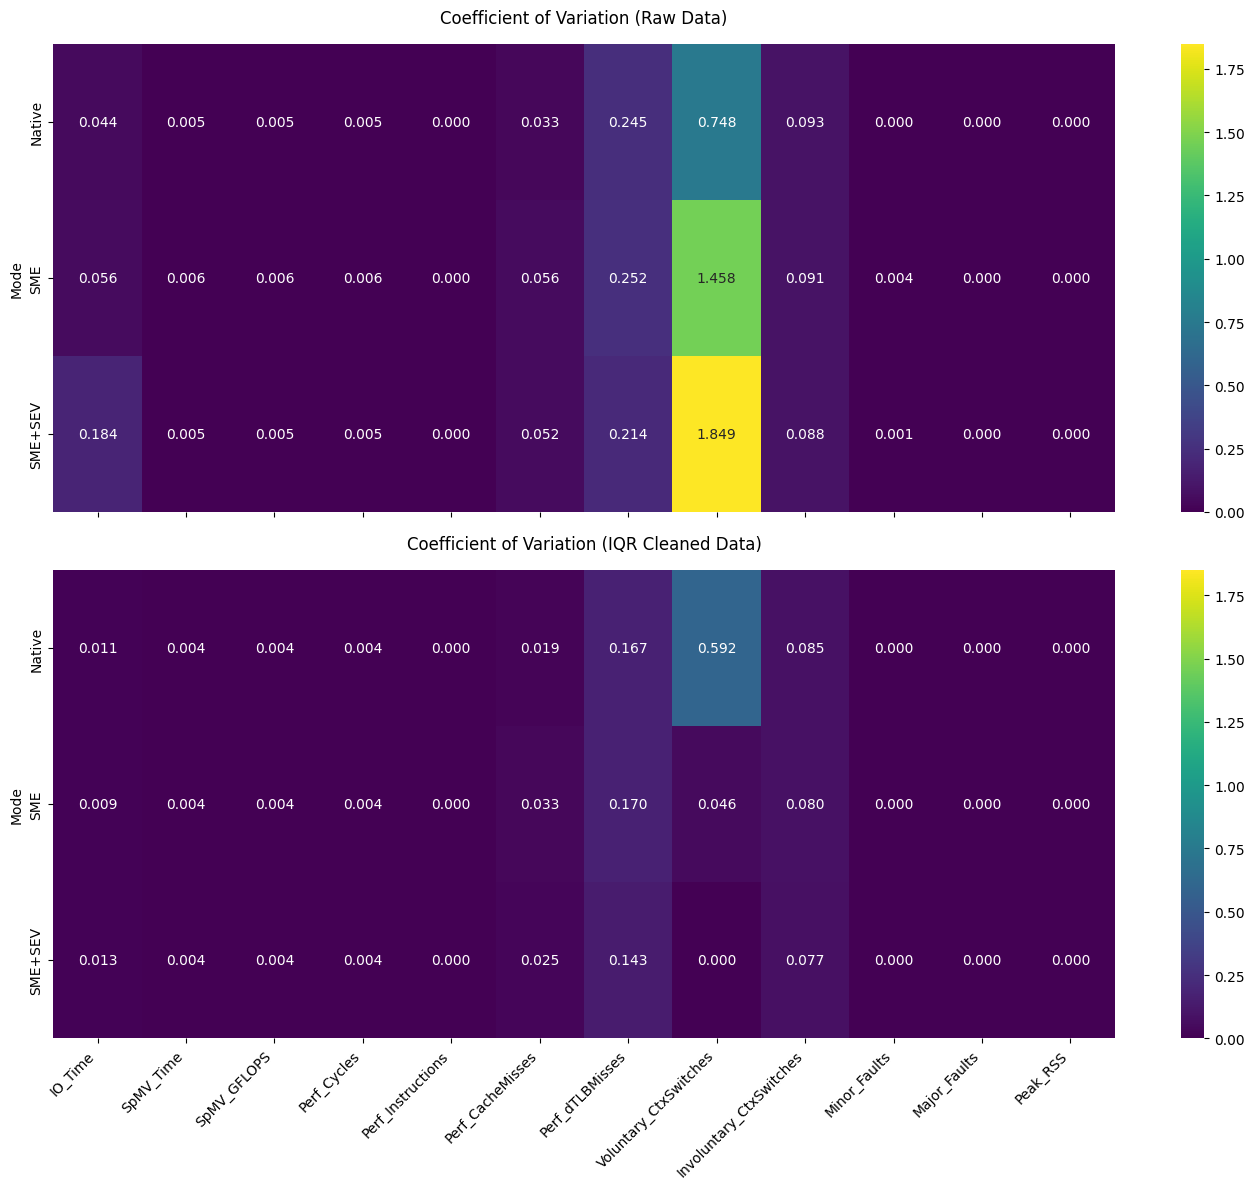

In [4]:
v_max = max(cv_raw_mode.max().max(), cv_clean_mode.max().max())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

kwargs = dict(
    annot=True,
    fmt=".3f",
    cmap="viridis",
    vmin=0,
    vmax=v_max
)

sns.heatmap(cv_raw_mode, ax=ax1, **kwargs)
ax1.set_title("Coefficient of Variation (Raw Data)", pad=15)
ax1.set_ylabel("Mode")

sns.heatmap(cv_clean_mode, ax=ax2, **kwargs)
ax2.set_title("Coefficient of Variation (IQR Cleaned Data)", pad=15)
ax2.set_ylabel("Mode")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [5]:
# fully cleaned data
df = (
    df_clean
    .groupby(config_cols)[metrics]
    .mean()
    .reset_index()
)

df['N'] = df['Matrix'].str.extract(r'N(\d+)').astype(int)
r = df['Matrix'].str.extract(r'(\d)-(\d)')
df['Randomness'] = (r[0] + "." + r[1]).astype(float)
df['MB'] = df.apply(lambda row: get_mb(row['N'], row['Randomness']), axis=1).astype('Int64')
k = 30  # nnz per row
#2 operations per non-zero element (multiply and add)
# TODO: the cpp gflops were calculated wrong, delete everything regarding that
df['SpMV_GFLOPS'] = ( 2 * k * df['N']) / ( (df['SpMV_Time'] / df['Iterations']) * 1e9)
#based on 32MB L3 per 8 cores
L3_size = {
    1: 32,
    8: 32,
    24: 96,
    48: 192,
}
df['L3_fit'] = df['MB'] >= df['Cores'].map(L3_size)

df.head()

,Mode,Matrix,Cores,Process_NUMA,VM_NUMA,Iterations,IO_Time,SpMV_Time,SpMV_GFLOPS,Perf_Cycles,...,Perf_dTLBMisses,Voluntary_CtxSwitches,Involuntary_CtxSwitches,Minor_Faults,Major_Faults,Peak_RSS,N,Randomness,MB,L3_fit
0,Native,0-0_N1440352.bin,1,interleave,interleave,369,0.081598,9.948493,3.205450,3.613541e+10,...,363828.533333,0.0,19.466667,7.0,0.0,535676.0,1440352,0.0,500,True
1,Native,0-0_N1440352.bin,1,interleave,strict,369,0.081996,9.993496,3.191015,3.630301e+10,...,396131.642857,0.0,16.466667,7.0,0.0,535676.0,1440352,0.0,500,True
2,Native,0-0_N1440352.bin,1,membind,interleave,369,0.081822,9.946006,3.206251,3.612827e+10,...,346667.800000,0.0,20.785714,7.0,0.0,535676.0,1440352,0.0,500,True
3,Native,0-0_N1440352.bin,1,membind,strict,369,0.081674,9.991400,3.191684,3.630452e+10,...,345576.933333,0.0,16.733333,7.0,0.0,535676.0,1440352,0.0,500,True
4,Native,0-0_N1440352.bin,8,interleave,interleave,713,0.081576,10.268875,6.000488,2.962678e+11,...,16662.933333,0.0,101.200000,17.0,0.0,540250.4,1440352,0.0,500,True


In [6]:
df_native = df[df['Mode'] == 'Native'].copy()
df_other = df[df['Mode'] != 'Native'].copy()

merge_cols = ['Matrix', 'Cores', 'Process_NUMA', 'VM_NUMA']

# additional columns to keep
extra_cols = ['N', 'Randomness', 'MB', 'L3_fit']

df_merged = df_other.merge(
    df_native[merge_cols + metrics],
    on=merge_cols,
    suffixes=('', '_native')
)

# include extra columns in result
result = df_merged[['Mode'] + merge_cols + extra_cols].copy()

for m in metrics:
    native_col = f"{m}_native"

    result[f"{m}_abs"] = df_merged[m] - df_merged[native_col]

    result[f"{m}_pct"] = np.where(
        df_merged[native_col] != 0,
        (df_merged[m] - df_merged[native_col]) / df_merged[native_col] * 100,
        np.nan
    )

overhead_df = result

Dimensions to visualize per Metric
Mode - 2 values
Matrix MB - 5 values
Matrix Randomness - 2 values
Cores - 4 values
VM NUMA Policy - 2 values
Process NUMA Policy - 2 values
= 6 Dimensions with 320 configs (cut down from 480 configs with the overhead_df)

How to visualize that?

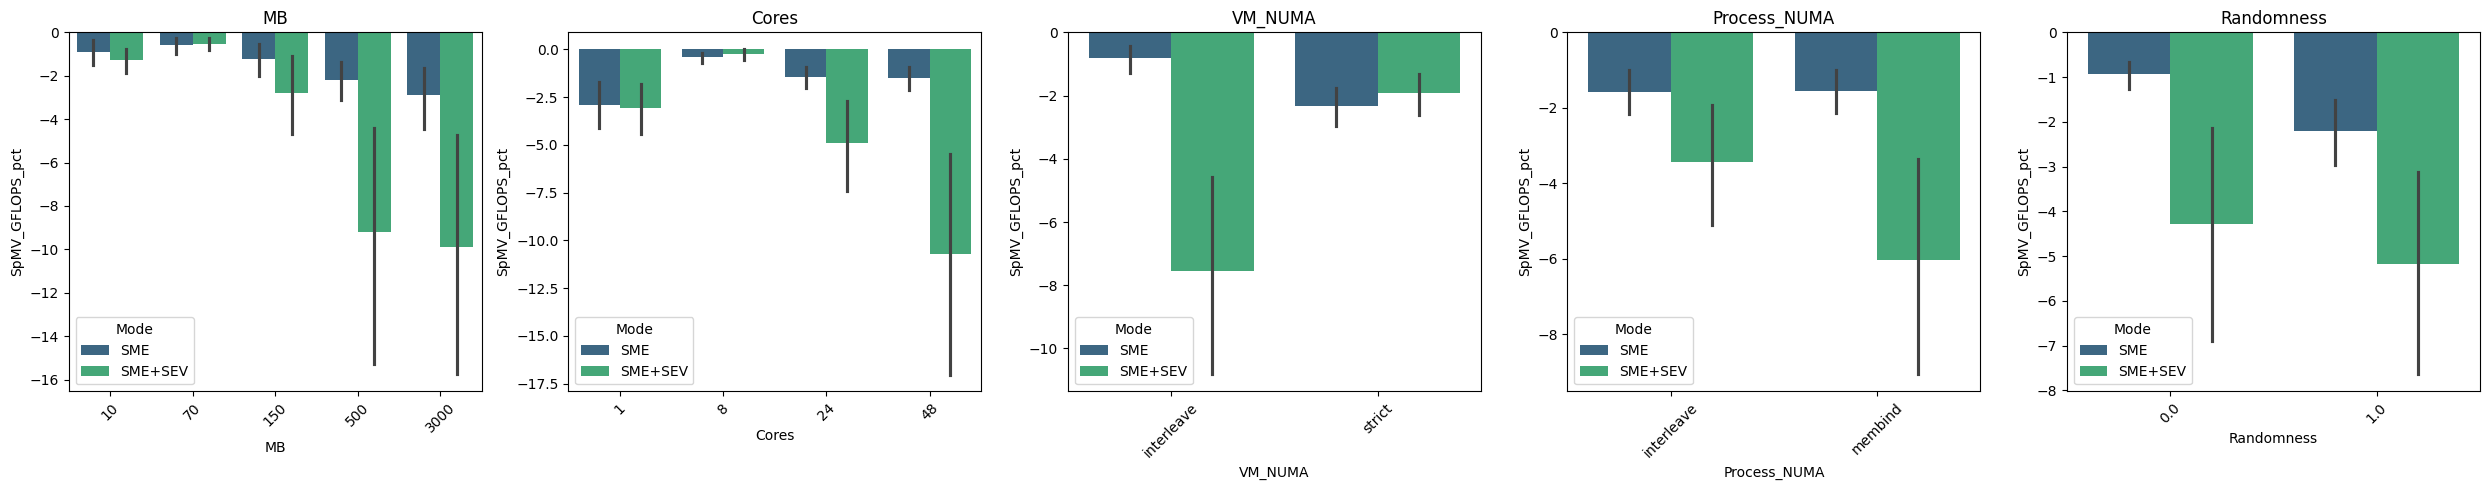

In [7]:
all_dims = ['MB', 'Cores', 'VM_NUMA', 'Process_NUMA', 'Randomness']

fig, axes = plt.subplots(nrows=1, ncols=len(all_dims), figsize=(5 * len(all_dims), 5))

for ax, a in zip(axes, all_dims):
    sns.barplot(
        data=overhead_df,
        x=a,
        y="SpMV_GFLOPS_pct",
        hue='Mode',
        palette="viridis",
        errorbar=("ci", 95),
        ax=ax
    )
    ax.set_title(a)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

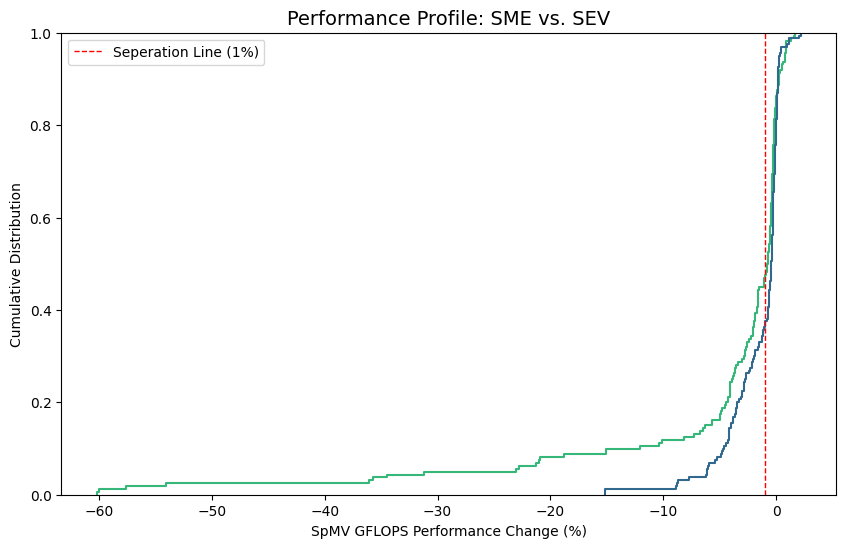

In [8]:
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=overhead_df, x="SpMV_GFLOPS_pct", hue="Mode", palette="viridis")

plt.axvline(x=-1, color='red', linestyle='--', linewidth=1, label='Seperation Line (1%)')
plt.title("Performance Profile: SME vs. SEV", fontsize=14)
plt.xlabel("SpMV GFLOPS Performance Change (%)")
plt.ylabel("Cumulative Distribution")
plt.legend()
plt.show()

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Global configuration: (Baseline/Low State, Stressed/High State)
# Order matters: Impact = High - Low
DIM_CONFIG = {
    'Randomness': (0, 1),
    'VM_NUMA': ('strict', 'interleave'),
    'Process_NUMA': ('membind', 'interleave'),
}

def get_impact_df(df, target_dim):
    """
    Calculates pairwise delta for target_dim using DIM_CONFIG.
    For MB/Cores, it defaults to (min, max).
    """
    all_dims = ['Mode', 'MB', 'Cores', 'VM_NUMA', 'Process_NUMA', 'Randomness']
    index_cols = [c for c in all_dims if c != target_dim]
    
    # Get comparison values
    if target_dim in DIM_CONFIG:
        low_val, high_val = DIM_CONFIG[target_dim]
    else:
        low_val, high_val = df[target_dim].min(), df[target_dim].max()
    
    # Pivot and calculate Delta
    pivot = df.pivot_table(
        index=index_cols, 
        columns=target_dim, 
        values='SpMV_GFLOPS_pct'
    ).reset_index()
    
    # Impact = 'Stressed' minus 'Baseline'
    pivot['Impact'] = pivot[high_val] - pivot[low_val]
    
    # Store metadata for the plotter to use in titles
    pivot.attrs['comparison'] = f"{low_val} → {high_val}"
    pivot.attrs['target'] = target_dim
    return pivot

def plot_impact_comparison(impact_df, compare_features):
    """
    Plots the impact with automated, descriptive titles.
    """
    target = impact_df.attrs.get('target', 'Dimension')
    comp_str = impact_df.attrs.get('comparison', '')
    
    fig, axes = plt.subplots(1, len(compare_features), figsize=(5 * len(compare_features), 5), sharey=True)
    
    # Ensure axes is always iterable even for 1 plot
    if len(compare_features) == 1: axes = [axes]

    for i, feat in enumerate(compare_features):
        # We pass the full DF to barplot to get automatic error bars (Standard Deviation)
        sns.barplot(
            data=impact_df, 
            x=feat, 
            y='Impact', 
            hue='Mode', 
            ax=axes[i], 
            palette='magma',
        )
        
        axes[i].axhline(0, linestyle='--', color='black', alpha=0.6)
        
        # KEY CHANGE: Descriptive Titles
        axes[i].set_title(f"Δ: {target}\n({comp_str})\nvs {feat}", fontsize=10)
        axes[i].tick_params(axis='x', rotation=45)
        
        if i == 0:
            axes[i].set_ylabel(f"Impact (% GFLOPS Change)")
        else:
            axes[i].set_ylabel("")
            
    plt.tight_layout()
    plt.show()


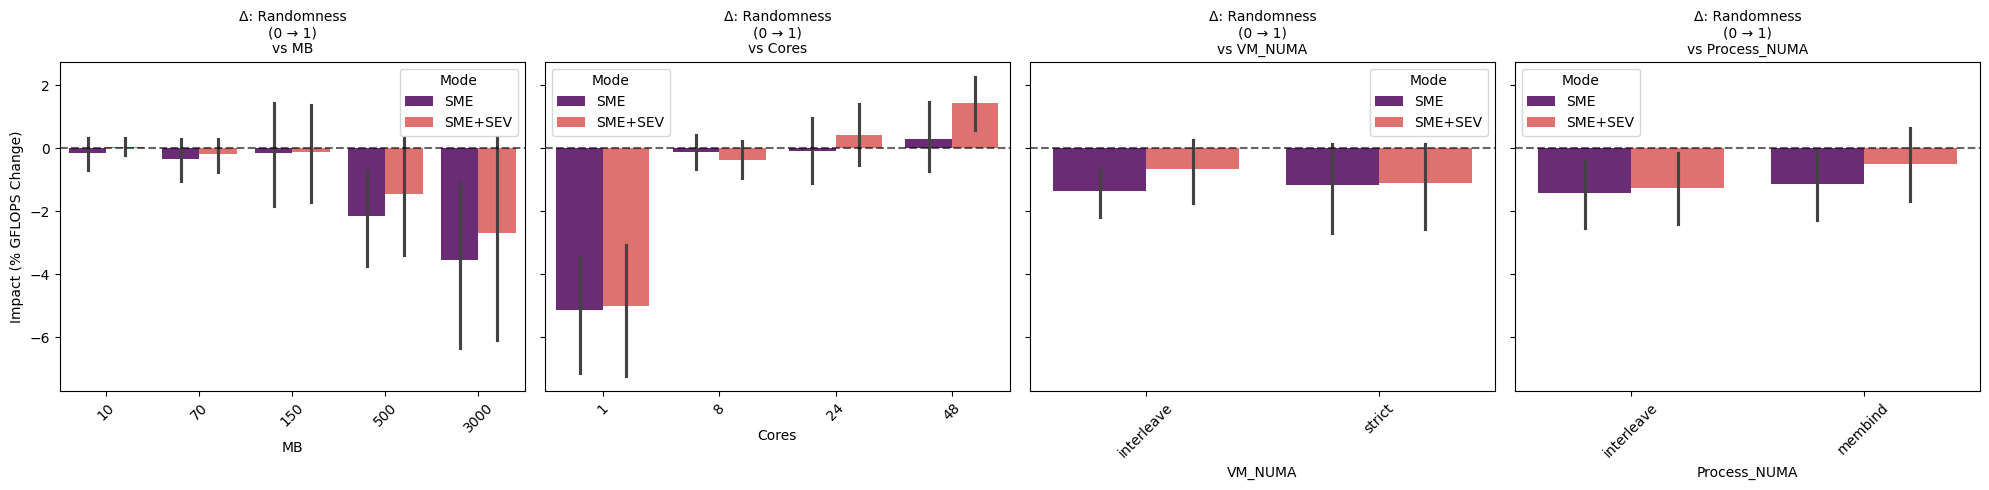

In [11]:
###Analyze Randomness Impact
rand_df = get_impact_df(overhead_df, 'Randomness')
plot_impact_comparison(rand_df, ['MB', 'Cores', 'VM_NUMA', 'Process_NUMA'])

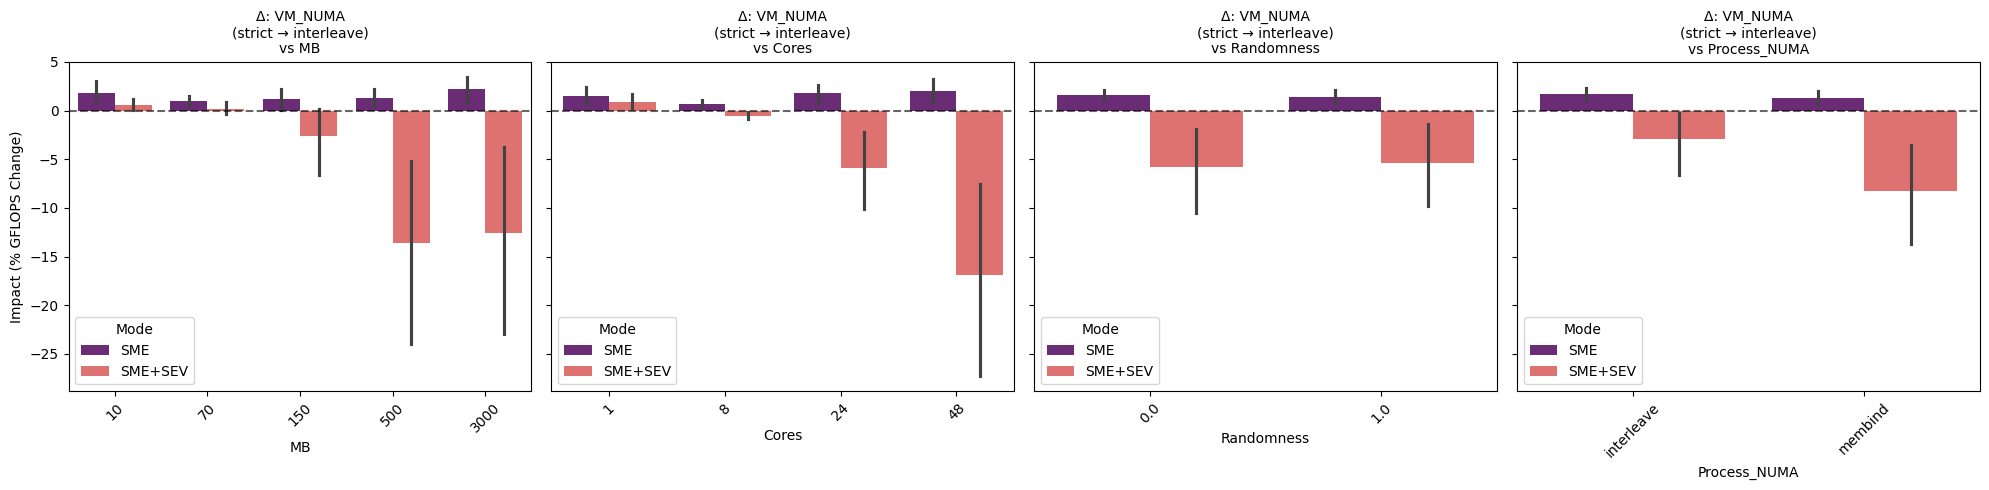

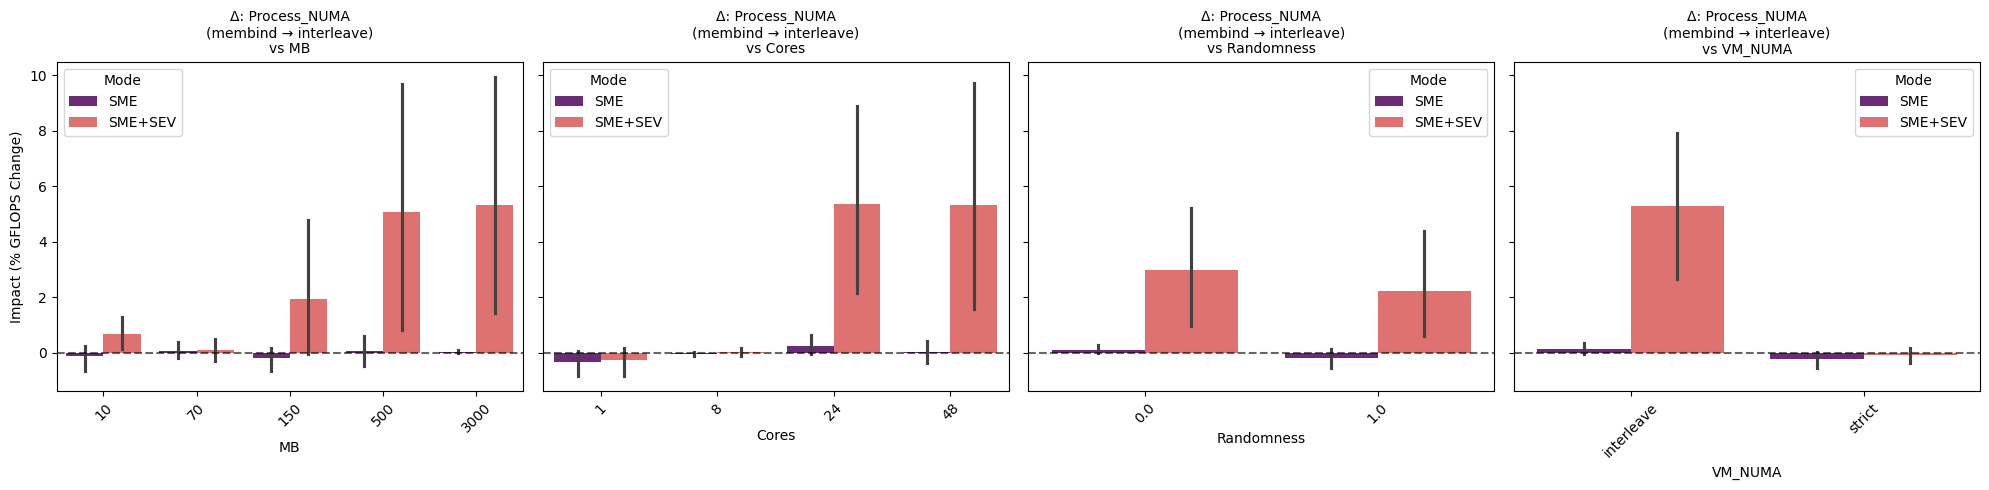

In [12]:
VM_NUMA_df = get_impact_df(overhead_df, 'VM_NUMA')
Process_NUMA_df = get_impact_df(overhead_df, 'Process_NUMA')
plot_impact_comparison(VM_NUMA_df, ['MB', 'Cores', 'Randomness', 'Process_NUMA'])
plot_impact_comparison(Process_NUMA_df, ['MB', 'Cores', 'Randomness', 'VM_NUMA'])